In [ ]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    # print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        print(event_dir)


                                        if os.path.exists(event_dir):
                                            print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, test_global_grad = parse_tf_events_file(event_dir, tag="Test/GradNorm")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            _, train_global_grad = parse_tf_events_file(event_dir, tag="Train/GradNorm")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'cifar10_accuracy_check'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

# availabilities="alphaF-0cb-3ft".split()
# availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-2cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-4cb-3ft alphaF-120sl-5cb-3ft alphaF-120sl-6cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-4cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-4cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft".split()
availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-2cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-4cb-3ft alphaF-120sl-5cb-3ft alphaF-120sl-6cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-4cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-4cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft alphaF-180sl-2cb-3ft alphaF-180sl-3cb-3ft alphaF-180sl-4cb-3ft alphaF-180sl-5cb-3ft alphaF-180sl-6cb-3ft alphaF-180sl-7cb-3ft alphaF-200sl-1cb-3ft alphaF-200sl-2cb-3ft alphaF-200sl-3cb-3ft alphaF-200sl-4cb-3ft alphaF-200sl-5cb-3ft alphaF-200sl-6cb-3ft alphaF-200sl-7cb-3ft".split() # list of availability matrices
# availabilities="alphaF-120sl-2cb-3ft alphaF-120sl-4cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-4cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-4cb-3ft alphaF-180sl-2cb-3ft alphaF-180sl-4cb-3ft alphaF-200sl-2cb-3ft alphaF-200sl-4cb-3ft".split() # list of availability matrices

main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = get_exp_stats(config)

results_df

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
# for availability_value, group in results_df.groupby("availability"):
    
#     plt.figure(figsize=(10, 6))
    
#     for _, row in group.iterrows():
#         label = f"lr={row['lr']} | seed={row['seed']}"
#         plt.plot(row['test_accuracy'], label=label)
    
#     plt.title(f"Test Accuracy Curves — availability = {availability_value}")
#     plt.xlabel("Epoch")
#     plt.ylabel("Test Accuracy")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10", seeds=["42", '78', '84'],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2','1e-2'], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=["alphaF-0cb-3ft"],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# results_df = load_experiment_results(config)
# # plot_availability_comparison_mean_seed(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat/ft')

../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-3cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-4cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-5cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-6cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-140sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-140sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-140

In [54]:
results_df['len']=results_df[['availability','seed','lr','test_accuracy']].apply(lambda x: len(x['test_accuracy']), axis=1)

In [55]:
results_df.loc[results_df['availability'] == 'alphaF-200sl-7cb-3ft']

,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,seed,lr,event,n_clients,biased,len
22,fedavg,alphaF-200sl-7cb-3ft,0.5,known,26.429999,10.00,"[0.10589999705553055, 0.11959999799728394, 0.1...",42,1e-1,global,7,2,201
45,fedavg,alphaF-200sl-7cb-3ft,0.5,known,25.540000,10.00,"[0.08489999920129776, 0.1518000066280365, 0.16...",78,1e-1,global,7,2,201
68,fedavg,alphaF-200sl-7cb-3ft,0.5,known,25.380000,10.00,"[0.10360000282526016, 0.11800000071525574, 0.1...",84,1e-1,global,7,2,201
101,fedavg,alphaF-200sl-7cb-3ft,0.5,known,26.240000,10.07,"[0.10170000046491623, 0.211899995803833, 0.229...",42,5e-2,global,7,2,201
134,fedavg,alphaF-200sl-7cb-3ft,0.5,known,28.610000,10.78,"[0.10199999809265137, 0.20550000667572021, 0.2...",78,5e-2,global,7,2,201
167,fedavg,alphaF-200sl-7cb-3ft,0.5,known,25.950000,8.30,"[0.10220000147819519, 0.16349999606609344, 0.1...",84,5e-2,global,7,2,201


In [56]:
results_df.loc[results_df['final_test_accuracy'] <= 20.0]

,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,seed,lr,event,n_clients,biased,len
17,fedavg,alphaF-180sl-7cb-3ft,0.5,known,22.250000,10.00,"[0.10589999705553055, 0.10589999705553055, 0.1...",42,1e-1,global,7,2,181
22,fedavg,alphaF-200sl-7cb-3ft,0.5,known,26.429999,10.00,"[0.10589999705553055, 0.11959999799728394, 0.1...",42,1e-1,global,7,2,201
40,fedavg,alphaF-180sl-7cb-3ft,0.5,known,19.830000,10.00,"[0.08489999920129776, 0.08489999920129776, 0.0...",78,1e-1,global,7,2,181
45,fedavg,alphaF-200sl-7cb-3ft,0.5,known,25.540000,10.00,"[0.08489999920129776, 0.1518000066280365, 0.16...",78,1e-1,global,7,2,201
68,fedavg,alphaF-200sl-7cb-3ft,0.5,known,25.380000,10.00,"[0.10360000282526016, 0.11800000071525574, 0.1...",84,1e-1,global,7,2,201
94,fedavg,alphaF-180sl-7cb-3ft,0.5,known,22.810000,10.00,"[0.10589999705553055, 0.10589999705553055, 0.1...",42,5e-2,global,7,2,181
101,fedavg,alphaF-200sl-7cb-3ft,0.5,known,26.240000,10.07,"[0.10170000046491623, 0.211899995803833, 0.229...",42,5e-2,global,7,2,201
127,fedavg,alphaF-180sl-7cb-3ft,0.5,known,22.560000,18.41,"[0.08489999920129776, 0.08489999920129776, 0.0...",78,5e-2,global,7,2,181
134,fedavg,alphaF-200sl-7cb-3ft,0.5,known,28.610000,10.78,"[0.10199999809265137, 0.20550000667572021, 0.2...",78,5e-2,global,7,2,201
160,fedavg,alphaF-180sl-7cb-3ft,0.5,known,19.159999,10.00,"[0.10360000282526016, 0.10360000282526016, 0.1...",84,5e-2,global,7,2,181


In [57]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

In [58]:
tmp = modify_data(results_df)
tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(100).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)
fed_avg.sort_values('avail_mat', inplace=True)

alpha_test_acc = fed_avg['final_mean_acc'].values * 100
base_test_acc = fed_avg.loc[fed_avg['avail_mat'] == 0, 'mean_test_acc'].values[0].take([100,90,75,60,45,30,15,5]) *100

In [59]:
perc_cb_used = [100.0,86.03754606747044,
 64.34157007056174,
 48.57710810495588,
 36.59564700520919,
 25.653291413710384,
 12.555690542858041,
 3.903694502135956
 ]

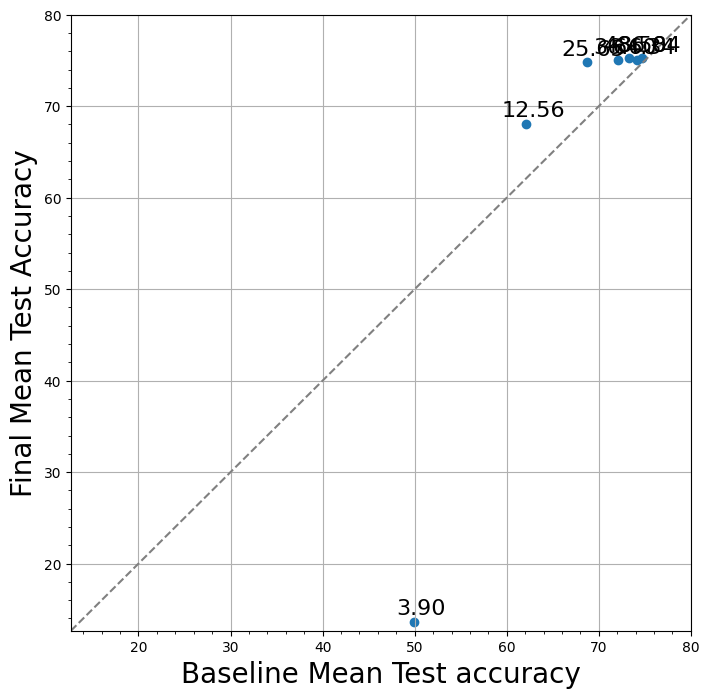

In [61]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc[1:],
    _tmp['final_mean_acc'].values[1:]*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values[1:]):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{perc_cb_used[i+1]:.2f}', 
        (base_test_acc[i+1],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )

x_min = min(min(base_test_acc[1:]), min(_tmp['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 80.0], [x_min-1, 80.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 80.0)
plt.ylim(x_min-1, 80.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()
